
# 2. Create a contour map

To start a new map, restart the kernal.

This tutorial page covers the basics of creating a figure of the Earth relief, using a
remote dataset hosted by GMT, using the method :meth:`pygmt.datasets.load_earth_relief`.
It will use the :meth:`pygmt.Figure.grdimage`, :meth:`pygmt.Figure.grdcontour`,
:meth:`pygmt.Figure.colorbar`, and :meth:`pygmt.Figure.coast` methods for plotting.


In [1]:
import pygmt

## Loading the Earth relief dataset

The first step is to use :meth:`pygmt.datasets.load_earth_relief`. The ``resolution``
parameter sets the resolution of the remote grid file, which will affect the
resolution of the plot made later in the tutorial. The ``registration`` parameter
determines the grid registration.

This grid region covers the islands of Guam and Rota in the western Pacific Ocean.



In [2]:
grid = pygmt.datasets.load_earth_relief(
    resolution="30s", region=[-131.04, -124, 47.44, 52.82], registration="gridline"
)

## Plotting Earth relief

To plot Earth relief data, the method :meth:`pygmt.Figure.grdimage` can be used to
plot a color-coded figure to display the topography and bathymetry in the grid file.
The ``grid`` parameter accepts the input grid, which in this case is the remote file
downloaded in the previous step. If the ``region`` parameter is not set, the region
boundaries of the input grid are used.

The ``cmap`` parameter sets the color palette table (CPT) used for portraying the
Earth relief. The :meth:`pygmt.Figure.grdimage` method uses the input grid to relate
the Earth relief values to a specific color within the CPT. In this case, the CPT
"oleron" is used; a full list of CPTs can be found at :gmt-docs:`reference/cpts.html`.



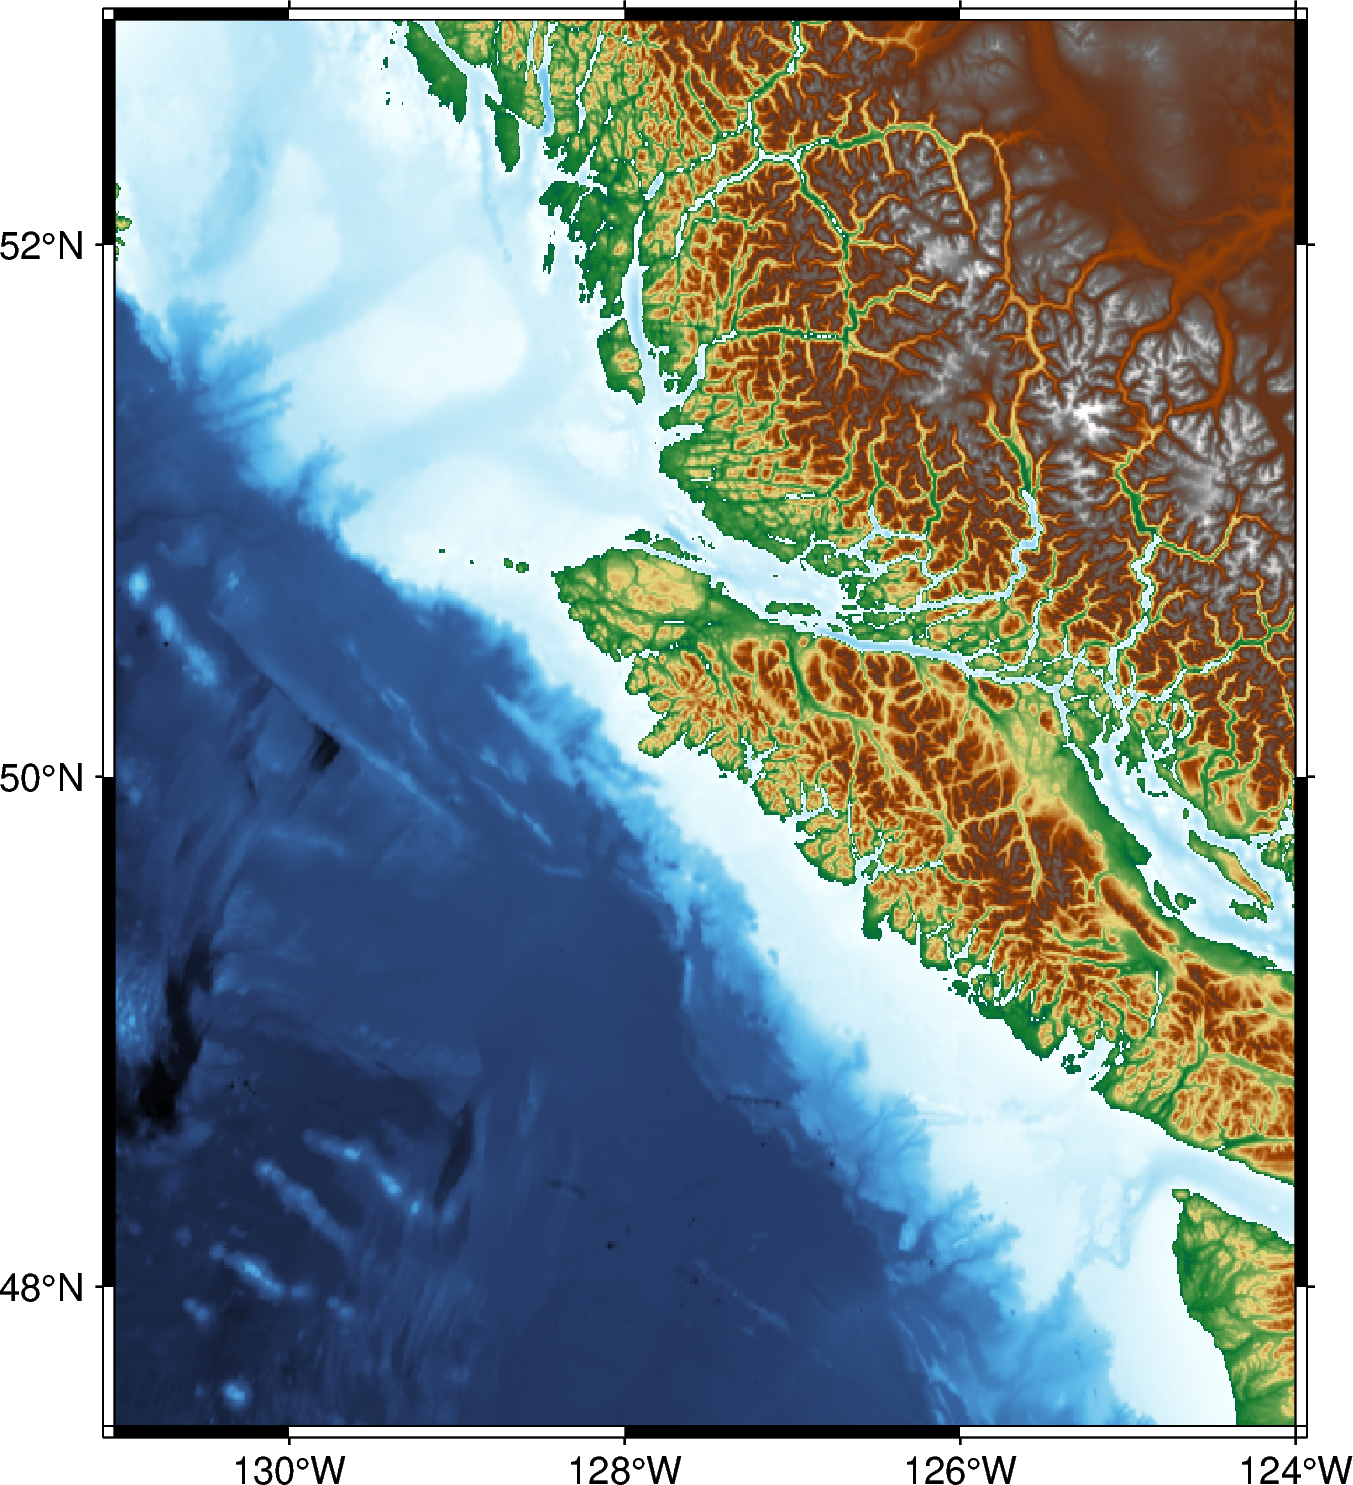

In [3]:
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="geo")
fig.show()

## Adding a colorbar

To show how the plotted colors relate to the Earth relief, a colorbar can be added
using the :meth:`pygmt.Figure.colorbar` method.

To control the annotation and labels on the colorbar, a list is passed to the
``frame`` parameter. The value beginning with ``"a"`` sets the interval for the
annotation on the colorbar, in this case every 1,000 meters. To set the label for an
axis on the colorbar, the argument begins with either ``"x+l"`` (x-axis) or ``"y+l"``
(y-axis), followed by the intended label.

By default, the CPT for the colorbar is the same as the one set in
:meth:`pygmt.Figure.grdimage`.



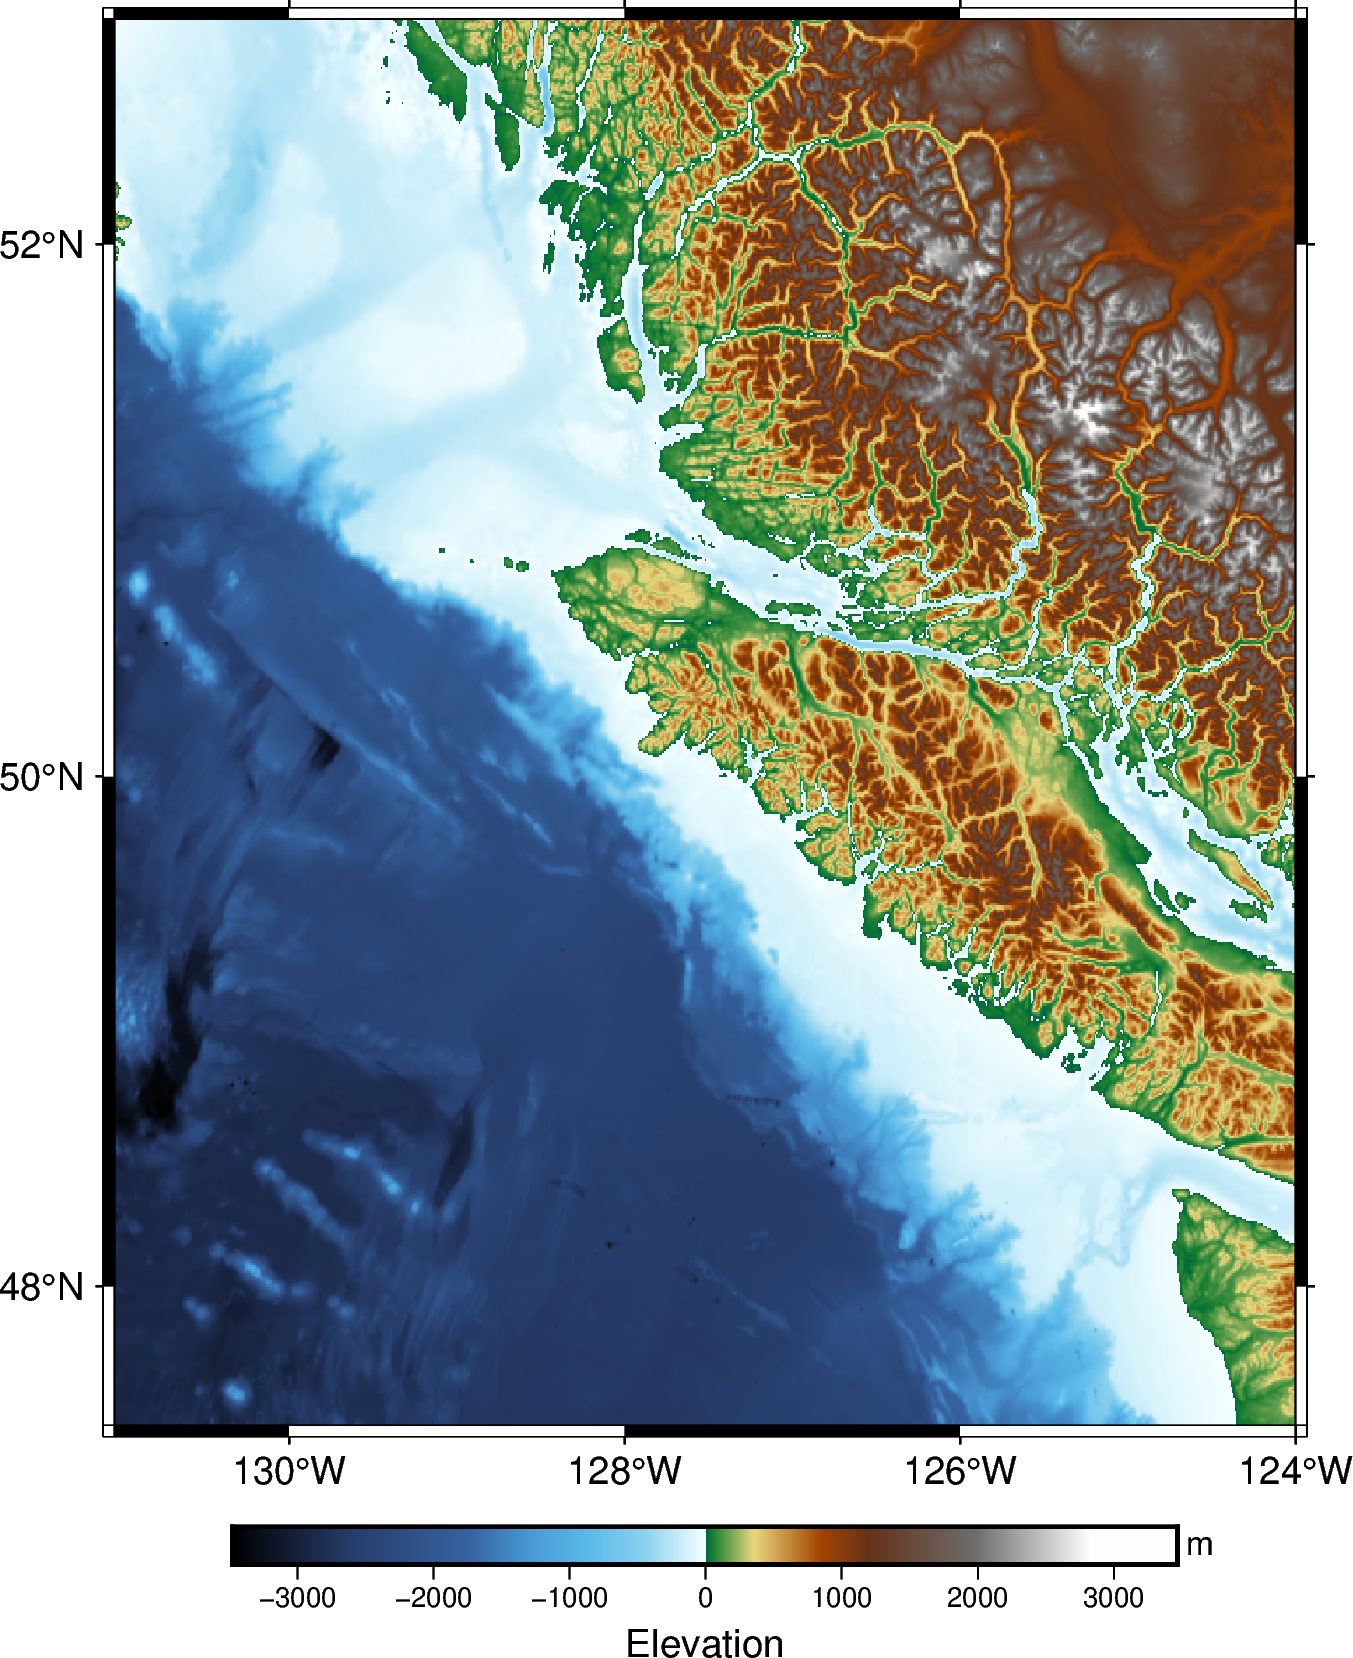

In [5]:
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="geo")
fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])
fig.show()

## Adding contour lines

To add contour lines to the color-coded figure, the :meth:`pygmt.Figure.grdcontour`
method is used. The ``frame`` and ``projection`` are already set using
:meth:`pygmt.Figure.grdimage` and are not needed again. However, the same input for
``grid`` (in this case, the variable named "grid") must be input again. The ``levels``
parameter sets the spacing between adjacent contour lines (in this case, 500 meters).
The ``annotation`` parameter annotates the contour lines corresponding to the given
interval (in this case, 1,000 meters) with the related values, here elevation or
bathymetry. By default, these contour lines are drawn thicker. Optionally, the
appearance (thickness, color, style) of the annotated and the not-annotated contour
lines can be adjusted (separately) by specifying the desired ``pen``.



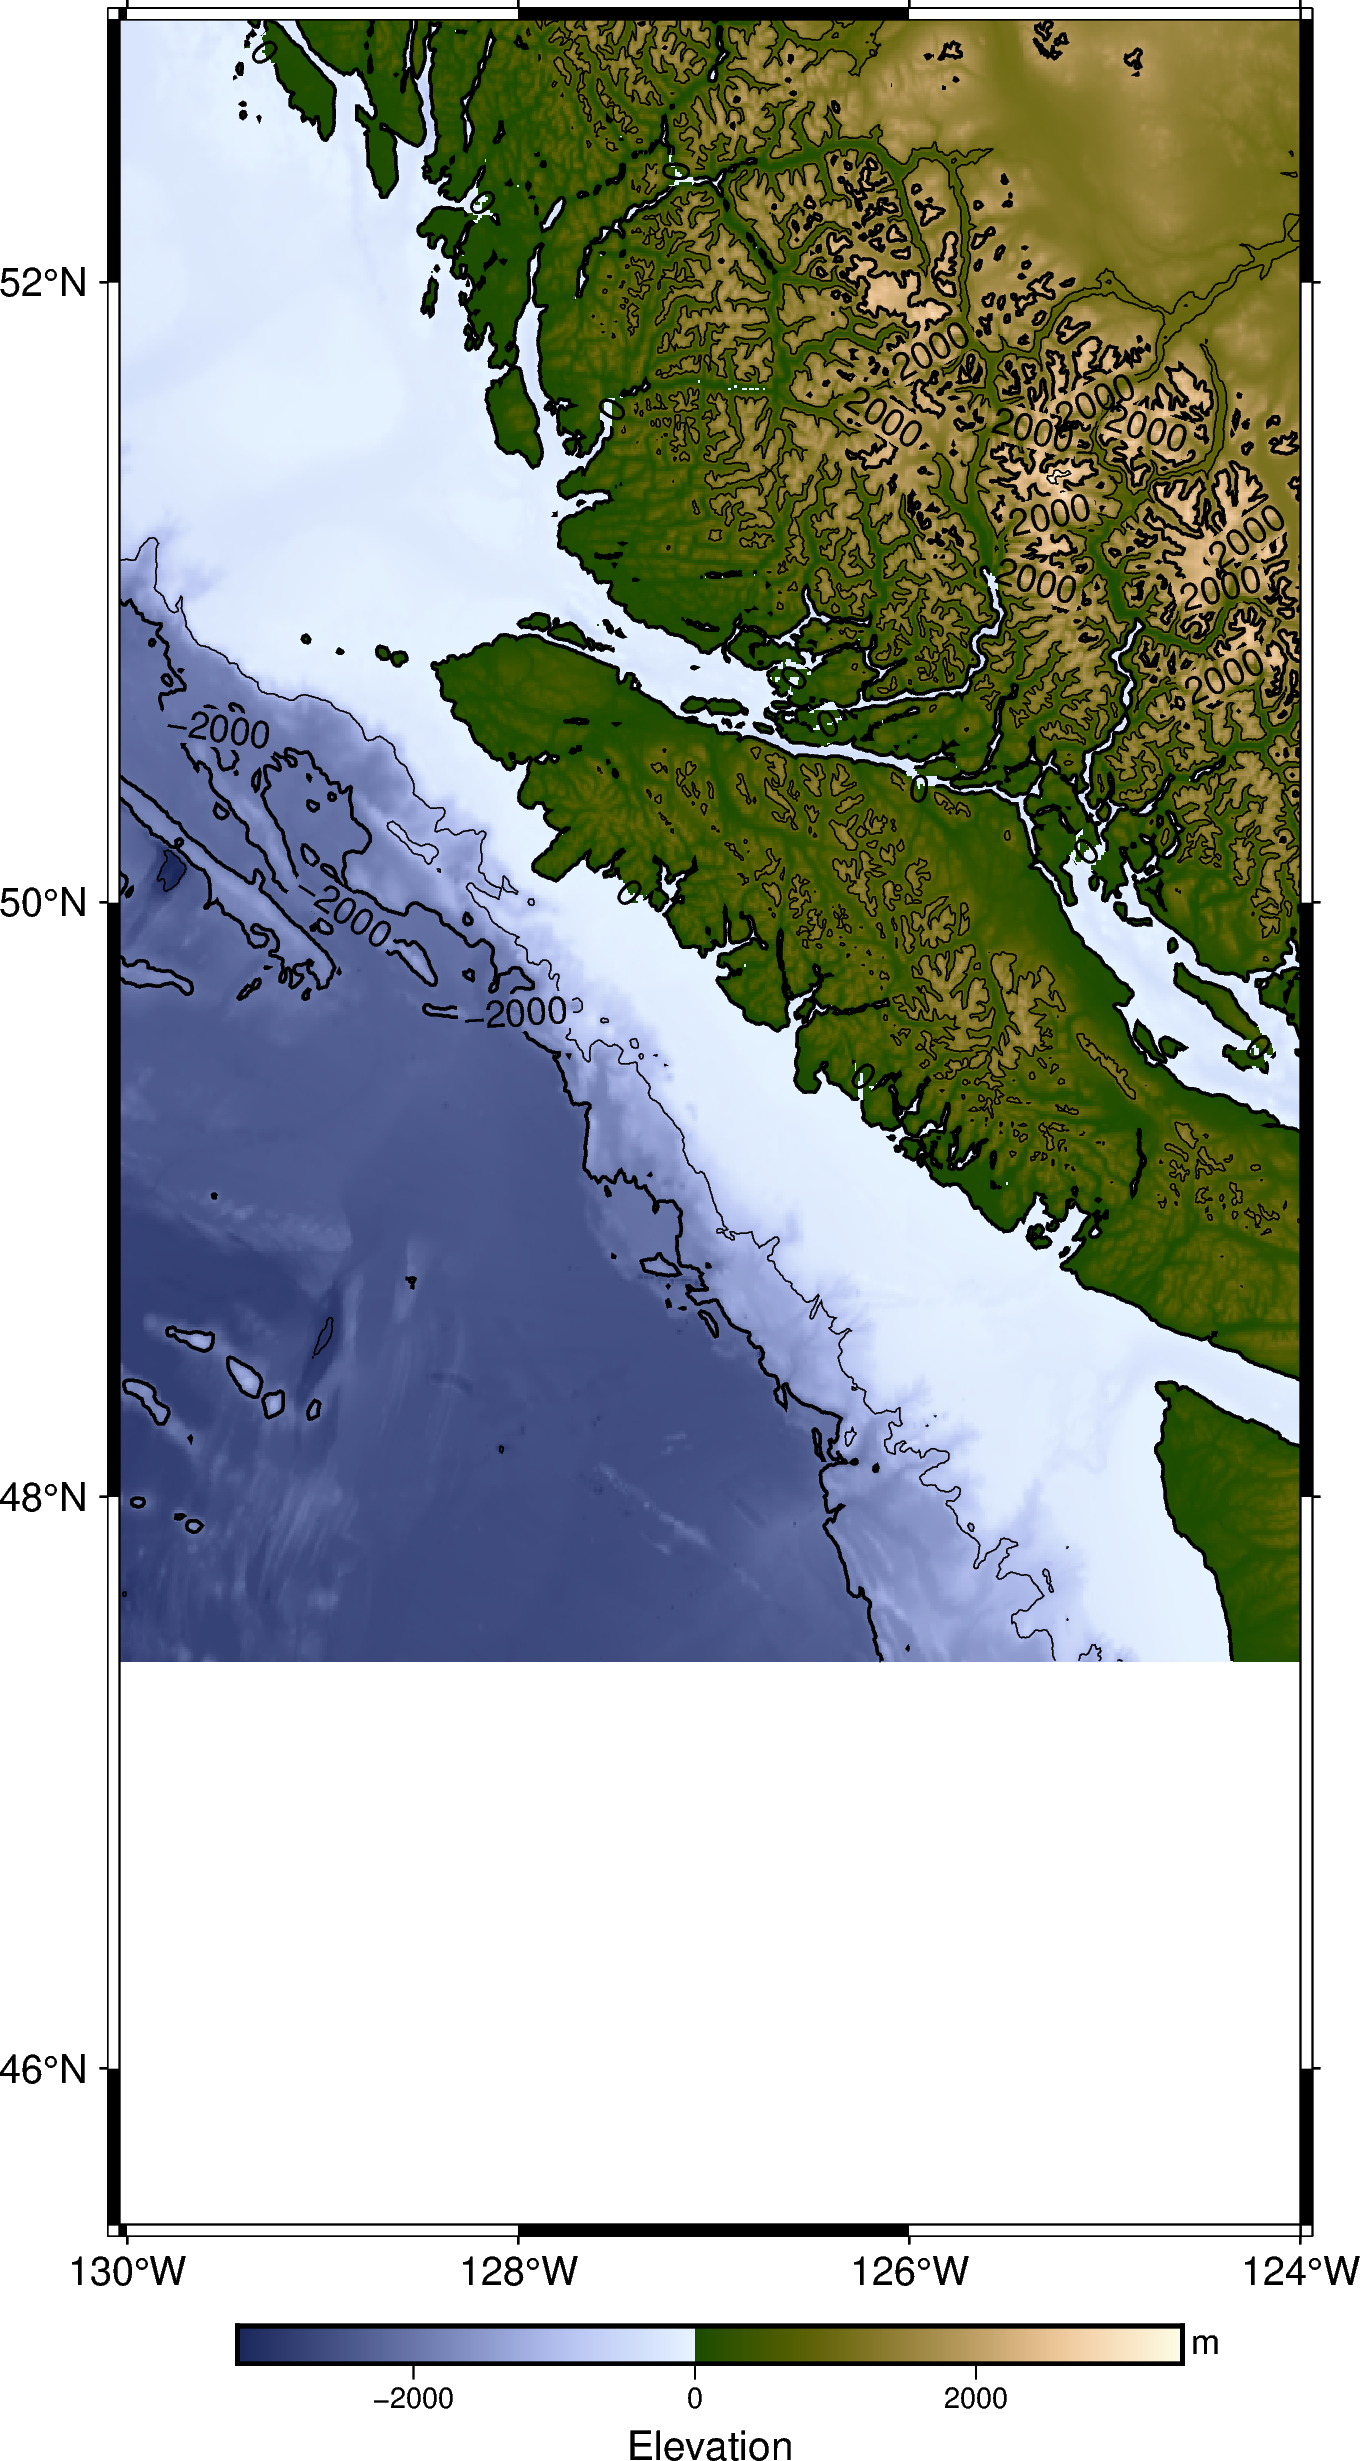

In [28]:
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="SCM/oleron")
fig.grdcontour(grid=grid, levels=1000, annotation=2000)
fig.colorbar(frame=["a2000", "x+lElevation", "y+lm"])
fig.show()

## Color in land

To make it clear where the islands are located, the :meth:`pygmt.Figure.coast` method
can be used to color in the landmasses. The ``land`` is colored in as "lightgray", and
the ``shorelines`` parameter draws a border around the islands.



In [ ]:
fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M10c", cmap="SCM/oleron")
fig.grdcontour(grid=grid, levels=500, annotation=1000)
fig.coast(shorelines="2p", land="lightgray")
fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])
fig.show()